In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
BASE = "../raw_csv"   # since notebook is in Week08/notebooks
print("BASE exists:", Path(BASE).exists())



BASE exists: True


In [3]:
import os
from pathlib import Path
import pandas as pd

BASE = "../raw_csv"

all_curves = []

for sub in sorted(os.listdir(BASE)):
    folder = Path(BASE) / sub
    if not folder.is_dir():
        continue

    for f in os.listdir(folder):
        # only Ag scan files
        if "ag" not in f.lower():
            continue
        if "scan" not in f.lower():
            continue

        path = folder / f
        print("Loading:", path)

        try:
            df = pd.read_csv(path)
        except Exception as e:
            print("Failed to read:", f, e)
            continue

        # normalize column names
        df.columns = [c.lower().strip() for c in df.columns]

        # normalize current column name
        rename_map = {
            "current density": "current",
            "j": "current"
        }
        df = df.rename(columns=rename_map)

        if "voltage" not in df.columns or "current" not in df.columns:
            print("Skipping (missing columns):", f, df.columns.tolist())
            continue

        df["voltage"] = pd.to_numeric(df["voltage"], errors="coerce")
        df["current"] = pd.to_numeric(df["current"], errors="coerce")
        df = df.dropna(subset=["voltage", "current"])

        # infer HTL from filename (before first underscore)
        htl = f.split("_")[0]

        df["HTL"] = htl
        df["Electrode"] = "Ag"
        df["SourceFile"] = f   # IMPORTANT for grouping later

        all_curves.append(df)

# combine all into one DataFrame
if all_curves:
    curves = pd.concat(all_curves, ignore_index=True)
else:
    curves = pd.DataFrame()

print("Total rows loaded:", len(curves))
curves.head()

Loading: ..\raw_csv\type2_breakdown_Ag\MeO2PACz_Ag_scan_10V.csv
Loading: ..\raw_csv\type2_breakdown_Ag\NiOx_Ag_scan_10V.csv
Loading: ..\raw_csv\type2_breakdown_Ag\PEDOT_Ag_scan_10V.csv
Loading: ..\raw_csv\type2_breakdown_Ag\polyTPD_Ag_scan_10V.csv
Loading: ..\raw_csv\type2_breakdown_Ag\PTAA_Ag_scan_10V.csv
Total rows loaded: 2305


,voltage,current,HTL,Electrode,SourceFile
0,1.50,-414.630968,MeO2PACz,Ag,MeO2PACz_Ag_scan_10V.csv
1,1.48,-385.656368,MeO2PACz,Ag,MeO2PACz_Ag_scan_10V.csv
2,1.46,-356.903254,MeO2PACz,Ag,MeO2PACz_Ag_scan_10V.csv
3,1.44,-328.702929,MeO2PACz,Ag,MeO2PACz_Ag_scan_10V.csv
4,1.42,-301.120664,MeO2PACz,Ag,MeO2PACz_Ag_scan_10V.csv


In [4]:
curves["HTL"].value_counts()

HTL
NiOx        601
PTAA        601
polyTPD     601
PEDOT       351
MeO2PACz    151
Name: count, dtype: int64

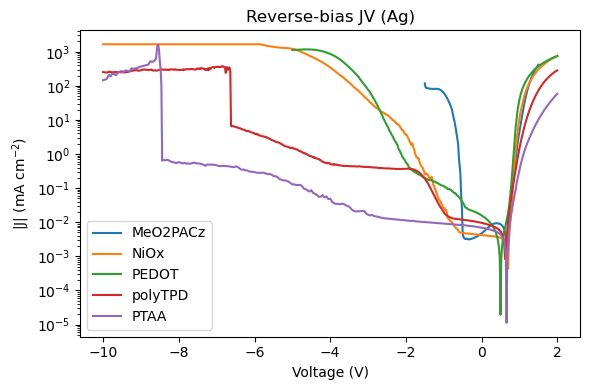

In [5]:
plt.figure(figsize=(6,4))

for htl in curves["HTL"].unique():
    g = curves[curves["HTL"] == htl].sort_values("voltage")
    plt.plot(g["voltage"], np.abs(g["current"]), label=htl)

plt.yscale("log")
plt.xlabel("Voltage (V)")
plt.ylabel("|J| (mA cm$^{-2}$)")
plt.title("Reverse-bias JV (Ag)")
plt.legend()
plt.tight_layout()
plt.show()

In [6]:
import numpy as np
from scipy.signal import savgol_filter

def extract_vbr_knee(df,
                     vmin=-0.2,
                     baseline_window=(-1.2, -0.4),
                     slope_factor=5,
                     max_logJ=2.5):
    """
    Vbr_knee = first reverse-bias voltage where slope of log(|J|) increases strongly
    compared to baseline leakage slope, while rejecting saturation plateau.
    Assumes current is already in mA/cm^2.
    """
    g = df.sort_values("voltage")
    g = g[g["voltage"] < vmin]

    V = g["voltage"].to_numpy()
    J = np.abs(g["current"].to_numpy())

    if len(V) < 15:
        return np.nan

    logJ = np.log10(J + 1e-12)

    # smooth to reduce noise
    if len(logJ) > 11:
        logJ = savgol_filter(logJ, 11, 2)

    dlogJ_dV = np.gradient(logJ, V)

    # baseline slope from mild reverse leakage region
    bm = (V >= baseline_window[0]) & (V <= baseline_window[1])
    base = np.median(dlogJ_dV[bm]) if bm.sum() >= 5 else np.median(dlogJ_dV)

    candidates = np.where(dlogJ_dV > slope_factor * base)[0]

    # pick first candidate that is NOT already saturated
    for i in candidates:
        if logJ[i] < max_logJ:
            return V[i]

    return np.nan


def extract_vbr_at_J_crossing(df, J_target=20.0):
    """
    Vbr_20mA = voltage where |J| crosses J_target from below (paper-like).
    Important: we sort in the direction 0 -> more negative voltage.
    Assumes current is already in mA/cm^2.
    """
    g = df.copy()
    g = g[g["voltage"] < 0]
    g = g.sort_values("voltage", ascending=False)  # 0 -> -10 (Ag)

    V = g["voltage"].to_numpy()
    J = np.abs(g["current"].to_numpy())

    if len(V) < 2:
        return np.nan

    for i in range(1, len(J)):
        if (J[i-1] < J_target) and (J[i] >= J_target):
            # linear interpolation for better Vbr estimate
            V0, V1 = V[i-1], V[i]
            J0, J1 = J[i-1], J[i]
            if J1 == J0:
                return V1
            return V0 + (J_target - J0) * (V1 - V0) / (J1 - J0)

    return np.nan

In [7]:
import pandas as pd

rows = []

for (htl, src), g in curves.groupby(["HTL", "SourceFile"]):
    rows.append({
        "HTL": htl,
        "SourceFile": src,
        "Vbr_knee": extract_vbr_knee(g),
        "Vbr_20mA": extract_vbr_at_J_crossing(g, J_target=20.0),
        "Electrode": "Ag"
    })

rows_df = pd.DataFrame(rows)

summary_df = (rows_df.groupby("HTL")[["Vbr_knee", "Vbr_20mA"]]
              .agg(["count", "mean", "std", "median", "min", "max"]))

rows_df, summary_df

(        HTL                SourceFile  Vbr_knee  Vbr_20mA Electrode
 0  MeO2PACz  MeO2PACz_Ag_scan_10V.csv     -1.50 -0.781925        Ag
 1      NiOx      NiOx_Ag_scan_10V.csv     -3.94 -2.706867        Ag
 2     PEDOT     PEDOT_Ag_scan_10V.csv     -3.44 -2.700465        Ag
 3      PTAA      PTAA_Ag_scan_10V.csv    -10.00 -8.443884        Ag
 4   polyTPD   polyTPD_Ag_scan_10V.csv    -10.00 -6.621024        Ag,
          Vbr_knee                                 Vbr_20mA                \
             count   mean std median    min    max    count      mean std   
 HTL                                                                        
 MeO2PACz        1  -1.50 NaN  -1.50  -1.50  -1.50        1 -0.781925 NaN   
 NiOx            1  -3.94 NaN  -3.94  -3.94  -3.94        1 -2.706867 NaN   
 PEDOT           1  -3.44 NaN  -3.44  -3.44  -3.44        1 -2.700465 NaN   
 PTAA            1 -10.00 NaN -10.00 -10.00 -10.00        1 -8.443884 NaN   
 polyTPD         1 -10.00 NaN -10.00 -10.00 -1

In [10]:
print(rows_df.head())

        HTL                SourceFile  Vbr_knee  Vbr_20mA Electrode
0  MeO2PACz  MeO2PACz_Ag_scan_10V.csv     -1.50 -0.781925        Ag
1      NiOx      NiOx_Ag_scan_10V.csv     -3.94 -2.706867        Ag
2     PEDOT     PEDOT_Ag_scan_10V.csv     -3.44 -2.700465        Ag
3      PTAA      PTAA_Ag_scan_10V.csv    -10.00 -8.443884        Ag
4   polyTPD   polyTPD_Ag_scan_10V.csv    -10.00 -6.621024        Ag


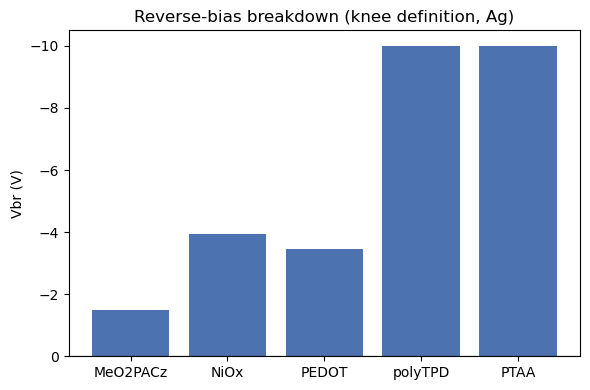

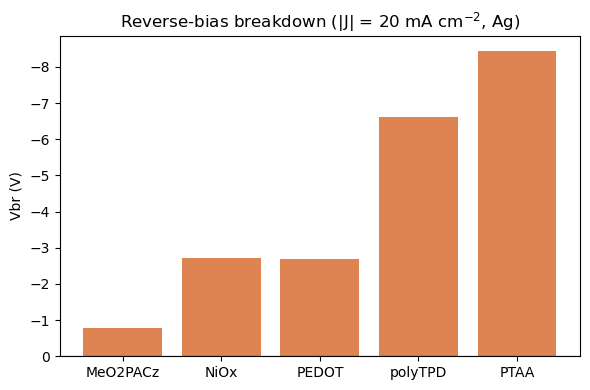

In [8]:
import matplotlib.pyplot as plt
import pandas as pd

# Make sure rows_df exists
if "rows_df" not in globals():
    raise RuntimeError("rows_df is not defined — please run Cell 6 first.")

# Correct HTL order
order = ["MeO2PACz", "NiOx", "PEDOT", "polyTPD", "PTAA"]
rows_df["HTL"] = pd.Categorical(rows_df["HTL"], categories=order, ordered=True)
rows_df = rows_df.sort_values("HTL")

# -------------------------
# Plot 1: Knee-based Vbr (Ag)
# -------------------------
plt.figure(figsize=(6,4))
plt.bar(rows_df["HTL"], rows_df["Vbr_knee"], color="#4C72B0")
plt.axhline(0, color="black", lw=0.8)
plt.ylabel("Vbr (V)")
plt.title("Reverse-bias breakdown (knee definition, Ag)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# -------------------------
# Plot 2: 20 mA-based Vbr (Ag)
# -------------------------
plt.figure(figsize=(6,4))
plt.bar(rows_df["HTL"], rows_df["Vbr_20mA"], color="#DD8452")
plt.axhline(0, color="black", lw=0.8)
plt.ylabel("Vbr (V)")
plt.title("Reverse-bias breakdown (|J| = 20 mA cm$^{-2}$, Ag)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


In [15]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Create folders
# -----------------------------
os.makedirs("../results", exist_ok=True)
os.makedirs("../figures", exist_ok=True)

# -----------------------------
# Save tables
# -----------------------------
rows_df.to_csv("../results/vbr_Ag_all_sync.csv", index=False)

summary_df = rows_df.groupby("HTL")[["Vbr_knee", "Vbr_20mA"]].mean().reset_index()
summary_df.to_csv("../results/vbr_Ag_summary_sync.csv", index=False)

# -----------------------------
# Save cleaned curves
# -----------------------------
curves.to_csv("../results/Ag_curves_cleaned_sync.csv", index=False)

# -----------------------------
# Save extraction parameters
# -----------------------------
params = {
    "extract_vbr_knee": {
        "vmin": -0.2,
        "baseline_window": [-1.2, -0.4],
        "slope_factor": 5,
        "max_logJ": 2.5
    },
    "extract_vbr_20mA": {
        "J_target": 20.0,
        "definition": "crossing from below to above as voltage decreases"
    }
}

with open("../results/Ag_extraction_parameters_sync.json", "w") as f:
    json.dump(params, f, indent=2)

# -----------------------------
# Save plots again (in case they weren't saved before)
# -----------------------------

order = ["MeO2PACz", "NiOx", "PEDOT", "polyTPD", "PTAA"]
rows_df["HTL"] = pd.Categorical(rows_df["HTL"], categories=order, ordered=True)
rows_df = rows_df.sort_values("HTL")

# Knee plot
plt.figure(figsize=(6,4))
plt.bar(rows_df["HTL"], rows_df["Vbr_knee"], color="#4C72B0")
plt.axhline(0, color="black", lw=0.8)
plt.ylabel("Vbr (V)")
plt.title("Reverse-bias breakdown (knee definition, Ag)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("../figures/Vbr_knee_Ag.png", dpi=300, bbox_inches="tight")
plt.close()

# 20 mA plot
plt.figure(figsize=(6,4))
plt.bar(rows_df["HTL"], rows_df["Vbr_20mA"], color="#DD8452")
plt.axhline(0, color="black", lw=0.8)
plt.ylabel("Vbr (V)")
plt.title("Reverse-bias breakdown (|J| = 20 mA cm$^{-2}$, Ag)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("../figures/Vbr_20mA_Ag.png", dpi=300, bbox_inches="tight")
plt.close()

# -----------------------------
# Write README
# -----------------------------
readme_text = """Ag reverse-bias analysis outputs (synchronized version)

Files:
- vbr_Ag_all_sync.csv        : per-device Vbr values (knee and 20mA)
- vbr_Ag_summary_sync.csv    : per-HTL averages
- Ag_curves_cleaned_sync.csv : cleaned JV curves used for extraction
- Vbr_knee_Ag.png            : knee-based breakdown plot
- Vbr_20mA_Ag.png            : 20 mA-based breakdown plot
- Ag_extraction_parameters_sync.json : parameters used for extraction

Definitions:
- Vbr_knee : knee point where slope of log(|J|) increases sharply
- Vbr_20mA : voltage where |J| crosses 20 mA/cm^2 from below
"""

with open("../results/README_Ag_sync.txt", "w") as f:
    f.write(readme_text)

# -----------------------------
# Confirmation
# -----------------------------
print("Saved synchronized Ag outputs:")
print("  ../results/vbr_Ag_all_sync.csv")
print("  ../results/vbr_Ag_summary_sync.csv")
print("  ../results/Ag_curves_cleaned_sync.csv")
print("  ../results/Ag_extraction_parameters_sync.json")
print("  ../results/README_Ag_sync.txt")
print("  ../figures/Vbr_knee_Ag.png")
print("  ../figures/Vbr_20mA_Ag.png")

C:\Users\Mazhar\AppData\Local\Temp\ipykernel_19508\3350993380.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary_df = rows_df.groupby("HTL")[["Vbr_knee", "Vbr_20mA"]].mean().reset_index()


Saved synchronized Ag outputs:
  ../results/vbr_Ag_all_sync.csv
  ../results/vbr_Ag_summary_sync.csv
  ../results/Ag_curves_cleaned_sync.csv
  ../results/Ag_extraction_parameters_sync.json
  ../results/README_Ag_sync.txt
  ../figures/Vbr_knee_Ag.png
  ../figures/Vbr_20mA_Ag.png


In [9]:
import pandas as pd

# Load saved synchronized Ag and Au summaries
ag = pd.read_csv("../results/vbr_Ag_summary_sync.csv")
au = pd.read_csv("../results/vbr_Au_summary.csv")

# Rename columns to avoid confusion
ag = ag.rename(columns={"Vbr_knee":"Vbr_knee_Ag", "Vbr_20mA":"Vbr_20mA_Ag"})
au = au.rename(columns={"Vbr_knee":"Vbr_knee_Au", "Vbr_20mA":"Vbr_20mA_Au"})

# Merge on HTL
comp = pd.merge(ag, au, on="HTL")

# Compute improvements (Au − Ag)
comp["ΔVbr_knee"] = comp["Vbr_knee_Au"] - comp["Vbr_knee_Ag"]
comp["ΔVbr_20mA"] = comp["Vbr_20mA_Au"] - comp["Vbr_20mA_Ag"]

comp


,HTL,Vbr_knee_Ag,Vbr_20mA_Ag,Vbr_knee_Au,Vbr_20mA_Au,ΔVbr_knee,ΔVbr_20mA
0,MeO2PACz,-1.50,-0.781925,-3.6395,-2.720382,-2.1395,-1.938457
1,NiOx,-3.94,-2.706867,-5.2995,-4.538829,-1.3595,-1.831962
2,PEDOT,-3.44,-2.700465,-10.0000,-4.320927,-6.5600,-1.620462
3,polyTPD,-10.00,-6.621024,-13.5000,-11.542340,-3.5000,-4.921316
4,PTAA,-10.00,-8.443884,-20.0000,-15.498514,-10.0000,-7.054630


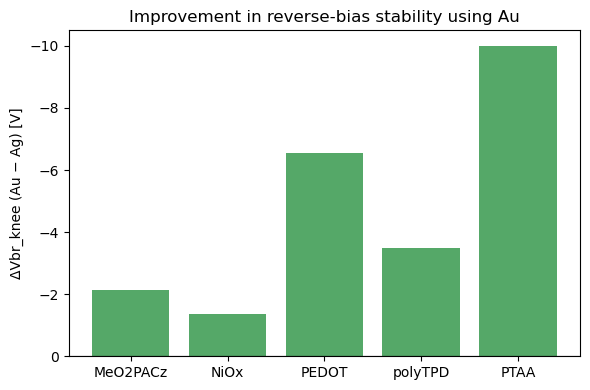

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.bar(comp["HTL"], comp["ΔVbr_knee"], color="#55A868")
plt.axhline(0, color="black", lw=0.8)
plt.ylabel("ΔVbr_knee (Au − Ag) [V]")
plt.title("Improvement in reverse-bias stability using Au")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [18]:
import os
import matplotlib.pyplot as plt

# Create folders if missing
os.makedirs("../results", exist_ok=True)
os.makedirs("../figures", exist_ok=True)

# -----------------------------
# Save comparison table
# -----------------------------
comp.to_csv("../results/vbr_Au_vs_Ag_comparison.csv", index=False)

# -----------------------------
# Save comparison plot again (so it's guaranteed saved)
# -----------------------------
plt.figure(figsize=(6,4))
plt.bar(comp["HTL"], comp["ΔVbr_knee"], color="#55A868")
plt.axhline(0, color="black", lw=0.8)
plt.ylabel("ΔVbr_knee (Au − Ag) [V]")
plt.title("Improvement in reverse-bias stability using Au")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("../figures/Vbr_improvement_Au_minus_Ag.png", dpi=300, bbox_inches="tight")
plt.close()

# -----------------------------
# Confirmation
# -----------------------------
print("Saved comparison outputs:")
print("  ../results/vbr_Au_vs_Ag_comparison.csv")
print("  ../figures/Vbr_improvement_Au_minus_Ag.png")


Saved comparison outputs:
  ../results/vbr_Au_vs_Ag_comparison.csv
  ../figures/Vbr_improvement_Au_minus_Ag.png


In [19]:
import pandas as pd

ag = pd.read_csv("../results/vbr_Ag_all_sync.csv")
au = pd.read_csv("../results/vbr_Au_all.csv")

master = pd.concat([ag, au], ignore_index=True)
master.to_csv("../results/vbr_master_Ag_Au.csv", index=False)

print("Saved: ../results/vbr_master_Ag_Au.csv")

Saved: ../results/vbr_master_Ag_Au.csv


In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))
for elec, sub in master.groupby("Electrode"):
    s = sub.groupby("HTL")["Vbr_knee"].mean().reindex(
        ["MeO2PACz","NiOx","PEDOT","polyTPD","PTAA"]
    )
    plt.plot(s.index, s.values, marker="o", label=elec)

plt.gca().invert_yaxis()
plt.axhline(0, color="black", lw=0.8)
plt.ylabel("Vbr_knee (V)")
plt.title("Reverse-bias breakdown comparison (Ag vs Au)")
plt.legend()
plt.tight_layout()
plt.savefig("../figures/Vbr_knee_Ag_vs_Au.png", dpi=300, bbox_inches="tight")
plt.close()

print("Saved: ../figures/Vbr_knee_Ag_vs_Au.png")

Saved: ../figures/Vbr_knee_Ag_vs_Au.png


In [12]:
comp[["HTL", "ΔVbr_knee", "ΔVbr_20mA"]]

,HTL,ΔVbr_knee,ΔVbr_20mA
0,MeO2PACz,-2.1395,-1.938457
1,NiOx,-1.3595,-1.831962
2,PEDOT,-6.5600,-1.620462
3,polyTPD,-3.5000,-4.921316
4,PTAA,-10.0000,-7.054630


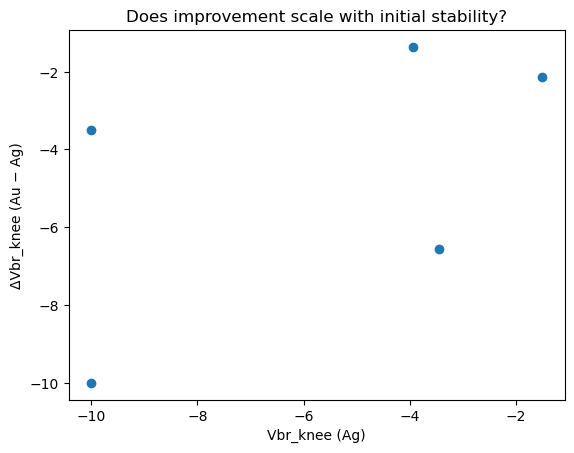

In [11]:
import matplotlib.pyplot as plt

plt.scatter(comp["Vbr_knee_Ag"], comp["ΔVbr_knee"])
plt.xlabel("Vbr_knee (Ag)")
plt.ylabel("ΔVbr_knee (Au − Ag)")
plt.title("Does improvement scale with initial stability?")
plt.show()

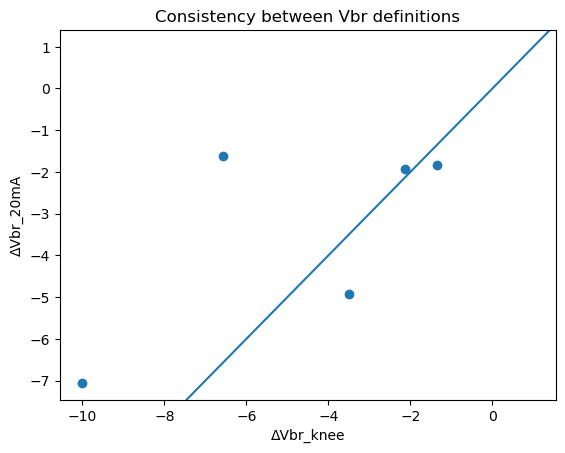

In [14]:
plt.scatter(comp["ΔVbr_knee"], comp["ΔVbr_20mA"])
plt.xlabel("ΔVbr_knee")
plt.ylabel("ΔVbr_20mA")
plt.title("Consistency between Vbr definitions")
plt.axline((0,0),(1,1))
plt.show()

In [12]:
import pandas as pd

# Load synchronized datasets
ag = pd.read_csv("../results/vbr_Ag_all_sync.csv")
au = pd.read_csv("../results/vbr_Au_all.csv")

# Standardize column names
ag["Electrode"] = "Ag"
au["Electrode"] = "Au"

# Combine
perov = pd.concat([ag, au], ignore_index=True)

# Select and order only ML-relevant columns
perov = perov[[
    "HTL",
    "Electrode",
    "Vbr_knee",
    "Vbr_20mA"
]]

# Save PerovAI dataset
perov.to_csv("../results/perovai_dataset.csv", index=False)

perov.head()

,HTL,Electrode,Vbr_knee,Vbr_20mA
0,MeO2PACz,Ag,-1.50,-0.781925
1,NiOx,Ag,-3.94,-2.706867
2,PEDOT,Ag,-3.44,-2.700465
3,polyTPD,Ag,-10.00,-6.621024
4,PTAA,Ag,-10.00,-8.443884


In [16]:
import json

metadata = {
    "description": "Reverse-bias breakdown voltage dataset for perovskite solar cells",
    "rows": "One row per device JV curve",
    "columns": {
        "HTL": "Hole transport layer material",
        "Electrode": "Top electrode material (Ag or Au)",
        "Vbr_knee": "Reverse-bias breakdown voltage from knee of log(|J|)-V curve (V)",
        "Vbr_20mA": "Reverse-bias voltage where |J| crosses 20 mA/cm^2 (V)"
    },
    "units": {
        "Vbr_knee": "V",
        "Vbr_20mA": "V"
    },
    "notes": [
        "Negative voltages indicate reverse bias",
        "More negative Vbr indicates higher stability",
        "Same extraction code used for Ag and Au"
    ]
}

with open("../results/perovai_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("Saved metadata to ../results/perovai_metadata.json")

Saved metadata to ../results/perovai_metadata.json


In [14]:
perov.to_parquet("../results/perovai_dataset.parquet", index=False)